## Implement Gradient Descent Algorithm for House Price Prediction


This is a template for Assignment 2 of **Optimization Algorithms**.

Fill in the **None** part in this template. Please don't change the template.
The goal in this assignment is to build a linear regression model to predict the house price based on its size.

In [18]:
# Put your code here (3 lines of code)
# Import numpy, pandas, and matplotlib.pyplot 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
# Put your code here (1 line of code)
# Load the dataset
data = pd.read_csv('house-prices.csv')

In [20]:
# Put your code here (1 line of code)
# Take a look at the data, use head method for data
data.head()

,Home,Price,SqFt,Bedrooms,Bathrooms,Offers,Brick,Neighborhood
0,1,114300,1790,2,2,2,No,East
1,2,114200,2030,4,2,3,No,East
2,3,114800,1740,3,2,1,No,East
3,4,94700,1980,3,2,3,No,East
4,5,119800,2130,3,3,3,No,East


In [21]:
# Select the size and price values from the dataset and assign them to 
# variables X and Y
X_dat = data['SqFt'].to_numpy()
Y_dat = data['Price'].to_numpy()

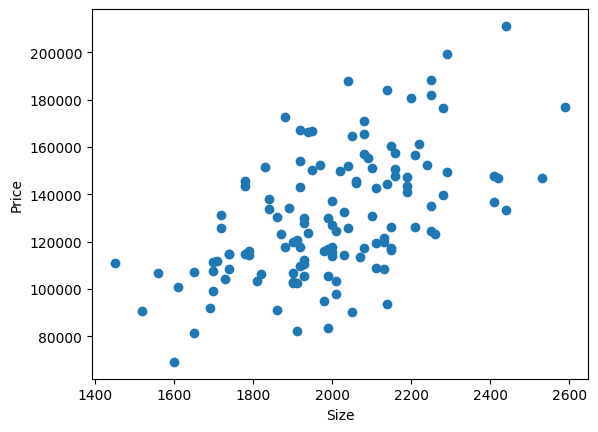

In [22]:
# Put your code here (1 line of code)
# Plot a scatter plot for X_dat and Y_dat
# Take a look at our data
plt.scatter(X_dat, Y_dat)

plt.xlabel('Size')
plt.ylabel('Price')
plt.show()

It is always good practice to normalize our data to increase the convergence rate of the Gradient Descent algorithm.

In [23]:
# Normalize our data
X = (np.max(X_dat) - X_dat)/(np.max(X_dat) - np.min(X_dat)) 
Y = (np.max(Y_dat) - Y_dat)/(np.max(Y_dat) - np.min(Y_dat)) 

Now that our data is prepared, let's start creating the necessary functions to implement the Gradient Descent algorithm.

### Linear Regression Model


At first step, we need to define our linear regression model. The model is as follows:

$$y=wx+b$$

In [24]:
# Define the linear regression model
def LR_model(x, w, b):
    # x: a scalar value, the size of the house
    # w: the weight of the model, a scalar value
    # b: the intercept of the model, a scalar value
    
    # Put your code here (1 line of code)
    # Define the linear regression model
    y = w * x + b
    
    return y

### Cost Function

Now, we need to define the cost function. The cost function is a mean squared error function. 

The mean squared error cost function for our linear regression can be formulated as:

$$J(w,b)=\dfrac{1}{2m} \sum_{i=1}^{m} {\left(\hat y^{(i)} - y^{(i)}\right)^2}= \dfrac{1}{2m} \sum_{i=1}^{m} {\left(wx^{(i)}+b - y^{(i)}\right)^2}$$



In [25]:
# Implement the cost function (mean squared error function)
def cost(X, Y, w, b):
    # X: a vector contains the size of the houses
    # Y: a vector contains the price of the houses
    # w: weight of the linear regression model
    # b: intercept of the model
    
    # Number of the observations
    m = X.shape[0]
    
    # Cost value
    
    # Put your code here (1 line of code)
    # Initilize the sum as zero 
    J = 0
    
    for i in range(m):
        x = X[i]
        y = Y[i]
        
        # Put your code here (1 line of code)
        # Use LR_model to compute the prediction of the price based on the size
        y_pred = w * x + b
        
        # Put your code here (1 line of code)
        # Compute the cost function (mean squared error cost function)
        J  += ((y_pred - y) ** 2) / (2 *m)
    
    return J
    

To make sure that you have correctly implemented the cost function, run the following cell and compare the obtained result with the given value. 

In [26]:
# Use your function to compute the cost for the following values
cost(X, Y, 2, 3)

6.050766241298438

The expected value is: 6.050766241298438

### Gradient Descent Update Rule


Now you need to implement the Gradient Descent update rule as follows:

$$ \qquad \left\{ \begin{array}{l} w_{n+1} = w_{n} -  \dfrac{\alpha}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right)x^{(i)} \\ b_{n+1} = b_{n} -  \dfrac{\alpha}{m} \sum_{i=1}^{m} \left( \hat{y}^{(i)} - y^{(i)} \right) \end{array} \right.$$


Here, $\alpha$ is the learning rate, $m$ is the number of the observations. Note that you are able to compute $\hat{y}^{(i)}$ using your previously developed function **LR_model**.

In [41]:
def grad_descent_step(X, Y, w, b, alf):
    # X: a vector contains the size of the houses
    # Y: a vector contains the price of the houses
    # w: weight of the linear regression model
    # b: intercept of the model
    # alf: learning rate (a scalar value)
    
    # Put your code here (1 line of code)
    # Number of the observations
    m = X.shape[0]
    
    # Put your code here (2 lines of code)
    # Initilize both sum_w and sum_b as zero
    sum_w = 0
    sum_b = 0
    
    # A for loop to compute the sums appear in the update rule
    for i in range(m):
        x = X[i]
        y = Y[i]
        
        # Put your code here (1 line of code)
        # Use your LR_model to compute a prediction with x, w, b
        y_pred = LR_model(x, w, b)
        
        # Put your code here (2 lines of code)
        # Compute the sums appear in the update rule
        sum_w = np.dot(X.T, (y_pred - Y)) / m
        sum_b = np.sum(y_pred - Y) / m
    
    # Put your codes here (2 lines of code)
    # Implement the update rule for the gradien descent
    w_new = w - alf * sum_w
    b_new = b - alf * sum_b
    
    return w_new, b_new

Now that you have implemented the Gradient Descent update rule, to ensure its correctness, run the following cell and compare your result with the provided one.

In [42]:
grad_descent_step(X, Y, 2, -3, 0.01)

(2.0155491374176275, -2.9702807000182108)

The expected values are as follows:
    
(2.0126078237441893, -2.97465021756207)

### Task 1: Implement Gradient Descent Algorithm

Now, it is time to implement the Gradient Descent algorithm using your already developed functions.

In [58]:
# Put your code here (1 line of code)
# Choose an initial value for w
w_init = 9

# Put your code here (1 line of code)
# Choose an initial value for b
b_init = 5

# Put your code here (1 line of code)
# Choose the learning rate
alf = 0.01

# Put your code here (1 line of code)
# Choose the number of iterations
N = 1000

# Save the values for w, b, and Cost 
W = np.zeros(N + 1)
B = np.zeros(N + 1)
C = np.zeros(N + 1)

# Save initial values
W[0] = w_init
B[0] = b_init

# Put your code here (1 line of code)
# Save the cost for w_init and b_init using cost function
C[0] = cost(X, Y, w_init, b_init)

# A loop to iteratively apply the update rule 
for n in range(N):
    
    # Put your code here (1 line of code)
    # Use grad_descent_step function to find new values for w, b
    w_new, b_new = grad_descent_step(X, Y, W[n], B[n], alf)
    
    # Put your code here (2 lines of code)
    # Save the new values for w and b 
    W[n+1] = w_new
    B[n+1] = b_new
    
    # Put your code here (1 line of code)
    # Save the cost value for compute new values of w and b 
    # Use the cost function you have already implemented
    C[n+1] = cost(X, Y, w_new, b_new)

Illustrate the cost function values against the algorithm's iterations. You have already stored these values in C. Now, plot them against the number of iterations.

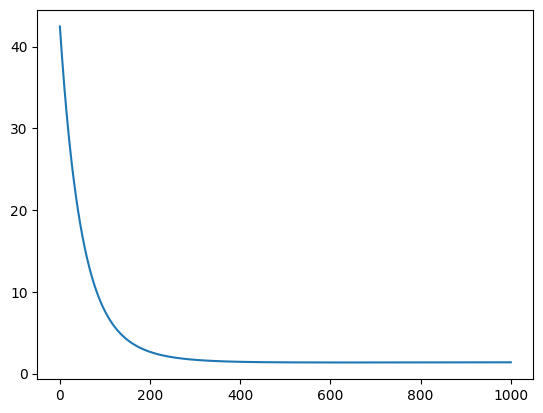

In [59]:
# Plot the results
# One line of code
plt.plot(range(N+1),C)
plt.show()

#### Reflection

Analyze the obtained graph and explain in the following cell why you think the Gradient Descent algorithm converges toward the optimal solution.

In [2]:
# Your answer
It converges because it updates itself based off of the derivatives.

Now, in the following cell plot the values of W (slope) against the iteration.

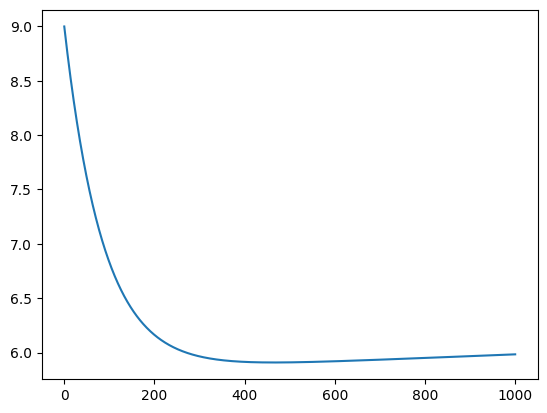

In [60]:
# Put your code here (1 line of code)
# Plot the saved values of W against the iteration.
plt.plot(range(N+1), W)

plt.show()

In the cell below, plot the values of B (intercept) against the iteration

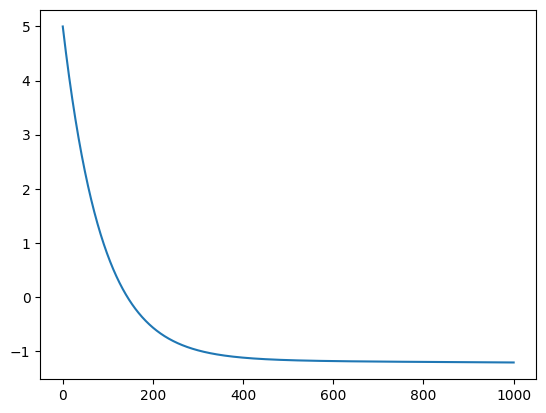

In [61]:
# Put your code here (1 line of code)
# Plot the saved values of B against the iteration.
plt.plot(range(N+1), B)

plt.show()

Represent the optimal value of b and w in the cell below:

In [62]:
# Put your code here (2 lines of code)
# Define the final values (optimal values) of w and b
w_opt = W[N]
b_opt = B[N]

print("The optimal value for w:", w_opt)
print("The optimal value for b:", b_opt)

The optimal value for w: 5.983181219825936
The optimal value for b: -1.2109961506137028


Since we initially normalized the data, in this section, we inverse the normalization to represent the model using the initial values of the data. plt.scatter(X_dat,Y_dat)

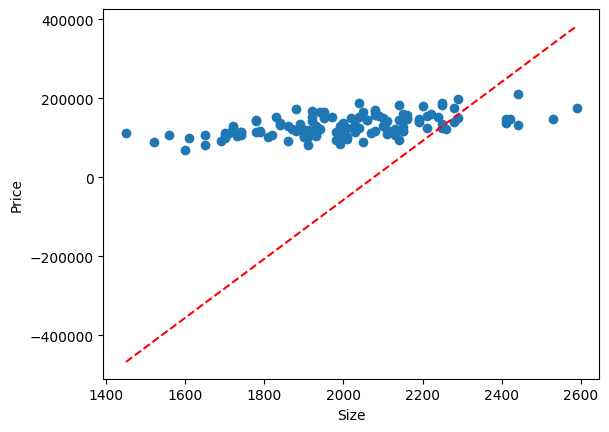

In [65]:
X_max = np.max(X_dat)
X_min = np.min(X_dat)

Y_max = np.max(Y_dat)
Y_min = np.min(Y_dat)

X_line = np.linspace(X_min, X_max, 100)
Y_line_norm = w_opt * (X_max - X_line)/(X_max - X_min) + b_opt
Y_line = Y_max - Y_line_norm * (Y_max - Y_min) 
plt.plot(X_line,Y_line, 'r--')

# Plot a scatter plot of the data here
# 1 line of code
plt.scatter(X_dat, Y_dat)

plt.xlabel('Size')
plt.ylabel('Price')
plt.show() 

### Compare with Scikit-learn


Congratulations! You have finished building a linear regression model from scratch. Perhaps you are curious to compare your model with the one obtained using the Scikit-learn package. In what follows, you will train the same model using Scikit-learn, and you can compare your model with that one.

In [66]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X.reshape(-1,1), Y)

In [67]:
print("The optimal value for w:", reg.coef_)

The optimal value for w: [0.563392]


In [68]:
print("The optimal value for b:", reg.intercept_)

The optimal value for b: 0.2773044733289968


If your model is significantly different from that of Scikit-learn, try to fine-tune the hyperparameters in your algorithm, such as the learning rate and the number of iterations. You should aim to achieve similar results.

#### Reflection

Compare the results from your implemented method with those obtained using Scikit-learn. If there are differences, explain why you think they occur. Describe what steps you took in your implementation to achieve a solution close to that of Scikit-learn, and detail any changes you applied.

In [3]:
# Your answer 
Differences due to small differences in GradBoost

Good luck!